# MLE Population Explorer

Notebook shell for reusable MLE exploration widgets. Backend logic lives in Python modules in this directory.

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 3
    import importlib, sys, pathlib
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


In [2]:
%matplotlib widget
from .data import load_mle_population_results, flatten_mle_results
from .histograms import show_latent_histogram_explorer
from .ddm_viewer import show_mle_ddm_viewer


## Load MLE Results

By default this loads `../data/RLModel/mle_*.pkl` from the project root and attaches matching `pp_*.pkl` files when present.

In [3]:
results = load_mle_population_results()
mle_population_df = flatten_mle_results(results)
len(results), mle_population_df.shape


(80, (441944, 39))

## Linked Latent Histograms

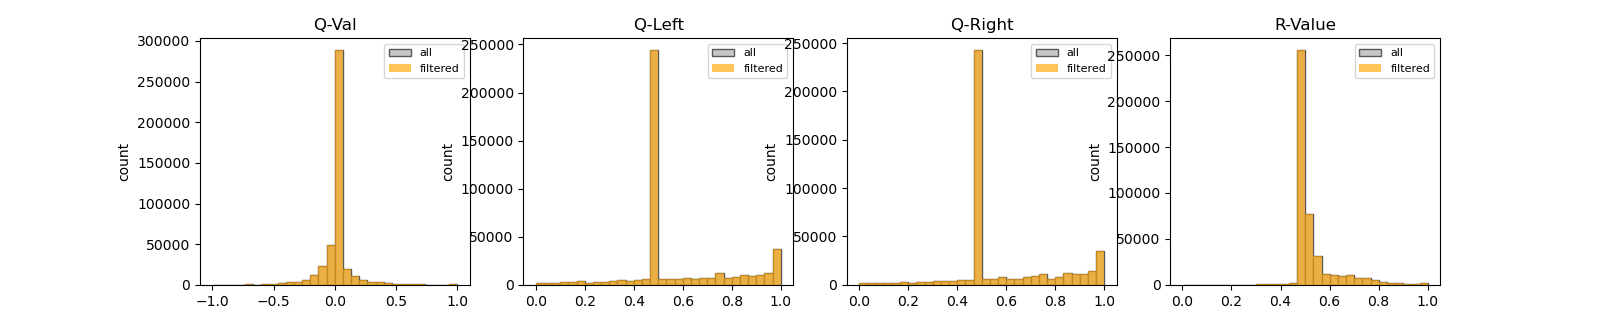

In [10]:
histogram_ui = show_latent_histogram_explorer(mle_population_df)


## DDM MLE Backend

In [5]:
import ipywidgets as widgets
from IPython.display import display

ddm_mle_backend = globals().get("ddm_mle_backend", "numpy")
ddm_backend_dropdown = widgets.Dropdown(
    options=[("NumPy", "numpy"), ("CuPy, fallback to NumPy", "cupy")],
    value=ddm_mle_backend if ddm_mle_backend in {"numpy", "cupy"} else "numpy",
    description="Backend",
)
ddm_backend_button = widgets.Button(description="Use backend", button_style="primary")
ddm_backend_status = widgets.HTML()

def _set_ddm_backend(_button=None):
    global ddm_mle_backend
    ddm_mle_backend = ddm_backend_dropdown.value
    ddm_backend_status.value = f"DDM MLE backend: <b>{ddm_mle_backend}</b>"

ddm_backend_button.on_click(_set_ddm_backend)
_set_ddm_backend()
display(widgets.HBox([ddm_backend_dropdown, ddm_backend_button, ddm_backend_status]))


## Single-Trial DDM Viewer

c:\Users\float\miniconda3\envs\py312\Lib\site-packages\jupyter_client\session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


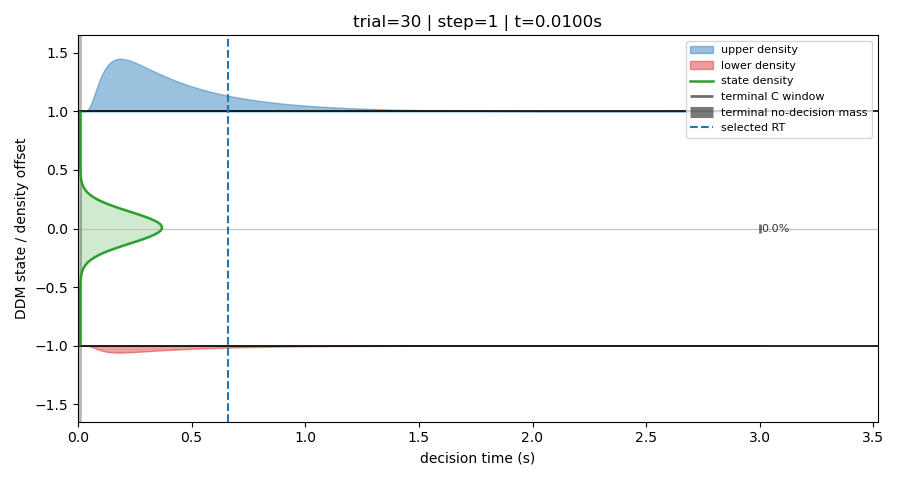

In [9]:
ddm_ui = show_mle_ddm_viewer(results, mle_array_backend=ddm_mle_backend)
